In [ ]:
import torch
from PIL import Image
from transformers import AutoTokenizer, CLIPImageProcessor, AutoModelForCausalLM, CLIPVisionModel, Qwen2VLForConditionalGeneration, AutoProcessor

In [2]:
class LLaVAMLP(torch.nn.Module):
    def __init__(self, vision_dim, text_dim):
        super().__init__()
        self.linear_1 = torch.nn.Linear(vision_dim, text_dim, bias=True)
        self.act = torch.nn.GELU()
        self.linear_2 = torch.nn.Linear(text_dim, text_dim, bias=True)

    def forward(self, image_features):
        return self.linear_2(self.act(self.linear_1(image_features)))

In [24]:
@torch.no_grad()
def generate(image_path, llm, vision_model, mlp, tokenizer, processor, device):
    IMAGE_TOKEN = '<img>'
    img_token_id = tokenizer.convert_tokens_to_ids(IMAGE_TOKEN)

    image = Image.open(image_path).convert("RGB")
    image_tensor = processor(images=image, return_tensors="pt")["pixel_values"].to(device)

    prompt = f"<|im_start|>user\n{IMAGE_TOKEN}\nDescribe this image.<|im_end|>\n<|im_start|>assistant\n"
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    text_embs = llm.get_input_embeddings()(input_ids)

    image_out = vision_model(image_tensor, output_hidden_states=True)
    image_features = image_out.hidden_states[-2][:, 1:]
    image_embs = mlp(image_features)#.to(text_embs.dtype)

    img_idx = (input_ids[0] == img_token_id).nonzero(as_tuple=True)[0][0]

    input_embs = torch.cat([
        text_embs[:, :img_idx, :], # b, sent_len, dim
        image_embs,
        text_embs[:, img_idx+1:, :]
    ], dim=1)

    output = llm.generate(
        inputs_embeds=input_embs,
        max_new_tokens = 50,
        do_sample = False, #griddy
        temperature = 0.0,
        pad_token_id = tokenizer.eos_token_id
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
def main():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    VISION_DIM = 768  
    TEXT_DIM = 896
    CHECKPOINT_PATH = "/kaggle/input/models/cvbnqq/a/pytorch/default/1/llava_mlp_epoch_3.pth"
    
    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
    tokenizer.add_tokens(["<img>"], special_tokens=True)
    processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch16")
    
    llm = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", torch_dtype=torch.float16).to(DEVICE)
    llm.resize_token_embeddings(len(tokenizer))
    vision_model = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch16", torch_dtype=torch.float16).to(DEVICE)
    
    mlp = LLaVAMLP(VISION_DIM, TEXT_DIM).to(DEVICE).half()

    test_img = "/kaggle/input/datasets/nagasai524/mini-coco2014-dataset-for-image-captioning/Images/COCO_train2014_000000000514.jpg"
    image = Image.open(test_img)
    display(image)

    out_before = generate(test_img, llm, vision_model, mlp, tokenizer, processor, DEVICE)
    print(f"Before train: {out_before}")

    mlp.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    out_after = generate(test_img, llm, vision_model, mlp, tokenizer, processor, DEVICE)
    print(f"after tain: {out_after}")

    #--
    sota_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", 
    torch_dtype=torch.float16, 
    device_map="auto"
)
    sota_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": test_img},
            {"type": "text", "text": "Describe this image."},
        ]}
    ]

    sota_text = sota_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    sota_inputs = sota_processor(text=[sota_text], images=[Image.open(test_img).convert("RGB")], return_tensors="pt").to(DEVICE)

    sota_output_ids = sota_model.generate(**sota_inputs, max_new_tokens=50)
    sota_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(sota_inputs.input_ids, sota_output_ids)]
    out_sota = sota_processor.batch_decode(sota_generated_ids, skip_special_tokens=True)[0]

    print(f"SOTA: {out_sota}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bia

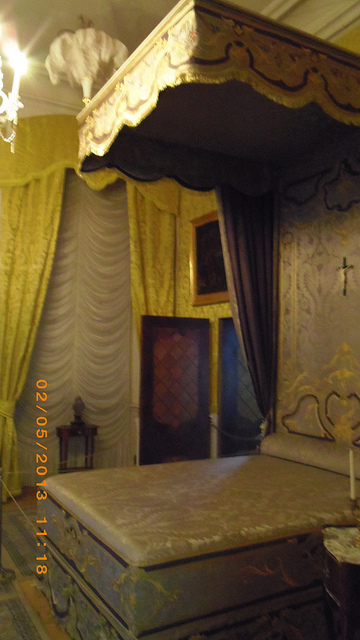

Before train: This image appears to be a mix of different elements, including:

1. **Characters**: The text seems to contain multiple characters or words that appear to be names or initials.
2. **Symbols and Characters**: There are symbols like `#`, `
after tain: A bed with a white sheet and a red pillow.


In [42]:
main()